
# Face PAD — Post-training Deep Evaluation (Kaggle)

Notebook này **không train lại model**. Mục tiêu là phân tích sâu model Spatial E1 sau khi train:

- kiểm tra runtime contract và threshold;
- chạy inference **một lần** trên Validation / Held-out Test rồi cache kết quả;
- APCER / BPCER / ACER / AUC / EER;
- ROC / DET;
- threshold sensitivity trên **Validation בלבד**;
- 3-class confusion matrix;
- score distributions: Real / Physical / Digital;
- per-attack-code breakdown;
- subject-level failure analysis;
- **subject-cluster bootstrap confidence intervals**;
- probability calibration / ECE / Brier score;
- worst False Accept / False Reject galleries;
- PyTorch ↔ ONNX parity;
- latency benchmark;
- optional robustness stress test;
- optional comparison với CSV do `camera_pad_diagnostic.py` sinh ra.

## Kaggle inputs cần add

1. **CelebA-Spoof dataset** đang dùng khi train.
2. Output/artifacts của notebook train v5.1, tối thiểu:
   - `*_best.pth`
   - `*_best_meta.json`
   - `*_runtime_config.json`
   - `celeba_spoof_subject_disjoint_*_split_seed42.npz`
   - `*_best.onnx` (khuyến nghị, để parity/runtime test)

> Notebook dùng exact split manifest của training run. Không tự split lại nếu manifest đã tồn tại.

> **Test policy:** notebook có thể đánh giá held-out Test vì đây là notebook post-training. Không dùng kết quả Test để quay lại tune E1. Mọi threshold analysis/operating-point selection chỉ được thực hiện trên Validation.


In [1]:

# Cell 1 — Environment
!pip install -q onnx onnxruntime scikit-learn pandas

import os, sys, json, math, time, hashlib, random
from pathlib import Path, PurePosixPath

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, roc_curve, det_curve, confusion_matrix,
    accuracy_score, brier_score_loss
)

try:
    import onnxruntime as ort
    ORT_AVAILABLE = True
except Exception as exc:
    ORT_AVAILABLE = False
    print("ONNX Runtime unavailable:", exc)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("OpenCV:", cv2.__version__)
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 65.0 MB/s eta 0:00:00
Python: 3.12.13
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
OpenCV: 4.13.0
Device: cuda
GPU: Tesla T4



## Cell 2 — Configuration & artifact discovery

Nếu auto-discovery tìm nhiều training output, hãy đặt `ARTIFACT_DIR` thủ công.

Ví dụ:

```python
ARTIFACT_DIR = Path("/kaggle/input/my-spatial-e1-output")
```

`DATA_ROOT` phải trỏ tới thư mục `CelebA_Spoof` chứa `metas/intra_test/...` và `Data/...`.


In [2]:

# Cell 2 — Configuration
DATA_ROOT = Path(
    "/kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/"
    "CelebA_Spoof_/CelebA_Spoof"
)

# Leave None to auto-discover under /kaggle/input.
ARTIFACT_DIR = "/kaggle/input/datasets/locngodev/model-trained/results"

EVALUATE_VALIDATION = True
EVALUATE_HELDOUT_TEST = True

BATCH_SIZE = 128
NUM_WORKERS = 4
FORCE_REINFER = False

BOOTSTRAP_REPS = 500
BOOTSTRAP_ALPHA = 0.05
CALIBRATION_BINS = 15
ERROR_GALLERY_N = 16

RUN_ONNX_PARITY = True
ONNX_PARITY_SAMPLES = 256

RUN_LATENCY_BENCHMARK = True
LATENCY_WARMUP = 30
LATENCY_ITERS = 200

# Optional extra inference. Keep False for the normal evaluation run.
RUN_ROBUSTNESS_STRESS = False
STRESS_SAMPLE_SIZE = 500

# Optional: after running camera_pad_diagnostic.py locally, upload its CSV to Kaggle
# and set this path to compare camera-real scores with CelebA real scores.
CAMERA_DIAGNOSTIC_CSV = "/kaggle/input/datasets/locngodev/camera-pad-diagnostic/camera_pad_diagnostic.csv"


def auto_discover_artifacts():
    root = Path("/kaggle/input")
    best_models = sorted(root.rglob("mnv3_e1_*_best.pth"))
    if not best_models:
        best_models = sorted(root.rglob("*_best.pth"))
    if not best_models:
        raise FileNotFoundError(
            "Không tìm thấy *_best.pth dưới /kaggle/input. "
            "Hãy Add Data output của notebook train hoặc đặt ARTIFACT_DIR."
        )

    # Prefer official artifacts when both preliminary and official are present.
    ranked = sorted(
        best_models,
        key=lambda p: (("official" in p.name.lower()), p.stat().st_size),
        reverse=True,
    )
    chosen = ranked[0]
    if len(ranked) > 1:
        print("⚠️ Multiple best checkpoints found:")
        for p in ranked[:10]:
            print(" -", p)
        print("Auto-selecting:", chosen)
    return chosen.parent


if ARTIFACT_DIR is None:
    ARTIFACT_DIR = auto_discover_artifacts()
else:
    ARTIFACT_DIR = Path(ARTIFACT_DIR)

print("DATA_ROOT   :", DATA_ROOT)
print("ARTIFACT_DIR:", ARTIFACT_DIR)

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"DATA_ROOT does not exist: {DATA_ROOT}")

TRAIN_JSON = DATA_ROOT / "metas/intra_test/train_label.json"
TEST_JSON = DATA_ROOT / "metas/intra_test/test_label.json"

best_candidates = sorted(ARTIFACT_DIR.glob("mnv3_e1_*_best.pth"))
if not best_candidates:
    best_candidates = sorted(ARTIFACT_DIR.glob("*_best.pth"))
if len(best_candidates) != 1:
    print("Best PTH candidates:", best_candidates)
    if not best_candidates:
        raise FileNotFoundError("No best .pth found in ARTIFACT_DIR")
BEST_PTH = best_candidates[0]

meta_candidates = sorted(ARTIFACT_DIR.glob("*_best_meta.json"))
runtime_candidates = sorted(ARTIFACT_DIR.glob("*_run_config.json")) or sorted(ARTIFACT_DIR.glob("*_runtime_config.json"))

manifest_candidates = sorted(ARTIFACT_DIR.glob("celeba_spoof_subject_disjoint_*_split_seed42.npz"))
onnx_candidates = sorted(ARTIFACT_DIR.glob("*_best.onnx"))

if not meta_candidates:
    raise FileNotFoundError("Missing *_best_meta.json")
if not runtime_candidates:
    raise FileNotFoundError("Missing *_runtime_config.json")
if not manifest_candidates:
    raise FileNotFoundError("Missing exact split manifest .npz")

BEST_META = meta_candidates[0]
RUNTIME_CONFIG = runtime_candidates[0]
SPLIT_MANIFEST = manifest_candidates[0]
ONNX_PATH = onnx_candidates[0] if onnx_candidates else None

print("BEST_PTH       :", BEST_PTH)
print("BEST_META      :", BEST_META)
print("RUNTIME_CONFIG :", RUNTIME_CONFIG)
print("SPLIT_MANIFEST :", SPLIT_MANIFEST)
print("ONNX           :", ONNX_PATH)


DATA_ROOT   : /kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof
ARTIFACT_DIR: /kaggle/input/datasets/locngodev/model-trained/results
BEST_PTH       : /kaggle/input/datasets/locngodev/model-trained/results/mnv3_e1_preliminary_v5_1_best.pth
BEST_META      : /kaggle/input/datasets/locngodev/model-trained/results/mnv3_e1_preliminary_v5_1_best_meta.json
RUNTIME_CONFIG : /kaggle/input/datasets/locngodev/model-trained/results/mnv3_e1_preliminary_v5_1_run_config.json
SPLIT_MANIFEST : /kaggle/input/datasets/locngodev/model-trained/results/celeba_spoof_subject_disjoint_preliminary_split_seed42.npz
ONNX           : None


In [3]:

# Cell 3 — Load runtime contract and assert threshold semantics
with open(BEST_META, "r") as f:
    best_meta = json.load(f)

with open(RUNTIME_CONFIG, "r") as f:
    runtime_cfg = json.load(f)

INPUT_SIZE = int(runtime_cfg.get("model_img_size", 224))
BBOX_EXPANSION_FACTOR = float(runtime_cfg.get("bbox_expansion_factor", 1.5))
CELEBA_MEAN = runtime_cfg.get("mean", [0.5931, 0.4690, 0.4229])
CELEBA_STD = runtime_cfg.get("std", [0.2471, 0.2214, 0.2157])
APPLY_GAMMA = bool(runtime_cfg.get("apply_gamma", False))

LOCKED_LOGIT_THRESHOLD = float(
    runtime_cfg.get(
        "calibrated_logit_threshold",
        best_meta.get("calibrated_logit_threshold")
    )
)
LOCKED_PROB_THRESHOLD = float(
    runtime_cfg.get(
        "predictor_threshold_probability",
        runtime_cfg.get(
            "calibrated_probability_threshold",
            best_meta.get("calibrated_probability_threshold")
        )
    )
)

def sigmoid_scalar(x):
    if x >= 0:
        z = math.exp(-x)
        return 1.0 / (1.0 + z)
    z = math.exp(x)
    return z / (1.0 + z)

expected_p = sigmoid_scalar(LOCKED_LOGIT_THRESHOLD)
print("Protocol version       :", runtime_cfg.get("protocol_version"))
print("Input size             :", INPUT_SIZE)
print("Crop expansion         :", BBOX_EXPANSION_FACTOR)
print("Color order            :", runtime_cfg.get("color_order"))
print("Mean / std             :", CELEBA_MEAN, CELEBA_STD)
print("Gamma                  :", APPLY_GAMMA)
print("Locked logit threshold :", LOCKED_LOGIT_THRESHOLD)
print("Runtime probability p  :", LOCKED_PROB_THRESHOLD)
print("sigmoid(logit threshold):", expected_p)

assert runtime_cfg.get("color_order", "RGB").upper() == "RGB"
assert APPLY_GAMMA is False, (
    "Research E1 baseline was defined as no-gamma. "
    "If this is a separate gamma deployment profile, evaluate/calibrate it separately."
)
assert abs(expected_p - LOCKED_PROB_THRESHOLD) < 1e-5, (
    "Threshold semantic mismatch: probability threshold != sigmoid(logit threshold)."
)


Protocol version       : spatial_e1_optimized_v5_1_time_balanced
Input size             : 224
Crop expansion         : 1.5
Color order            : None
Mean / std             : [0.5931, 0.469, 0.4229] [0.2471, 0.2214, 0.2157]
Gamma                  : False
Locked logit threshold : -0.682607114315033
Runtime probability p  : 0.3356796703127529
sigmoid(logit threshold): 0.3356796703127529


In [4]:

# Cell 4 — Dataset / preprocessing helpers (runtime-aligned, NO augmentation, NO gamma)
def label_of(meta_value):
    raw = int(meta_value[40])
    if raw == 0:
        return 0
    if raw in [1, 2, 3, 4, 5, 6, 7]:
        return 1
    return 2

def attack_code_of(meta_value):
    return int(meta_value[40])

# Only names that are already verified in the project are named explicitly.
# Unknown/raw codes remain visible instead of guessing the dataset taxonomy.
ATTACK_NAME_HINTS = {
    0: "Live",
    3: "Face Mask",
    5: "Region Mask",
}

def attack_name(code):
    code = int(code)
    return ATTACK_NAME_HINTS.get(code, f"Attack code {code}")

def subject_id_from_relpath(rel_path):
    parts = PurePosixPath(str(rel_path).replace("\\", "/")).parts
    for i, part in enumerate(parts[:-1]):
        if part.lower() in {"train", "test"} and i + 1 < len(parts):
            return parts[i + 1]
    raise ValueError(f"Cannot infer subject id from: {rel_path}")

def runtime_crop_bgr(img, bbox_xyxy, bbox_expansion_factor=BBOX_EXPANSION_FACTOR):
    original_height, original_width = img.shape[:2]
    x1, y1, x2, y2 = bbox_xyxy
    w, h = x2 - x1, y2 - y1
    if w <= 0 or h <= 0:
        raise ValueError(f"Invalid bbox: {bbox_xyxy}")

    max_dim = max(w, h)
    center_x = x1 + w / 2
    center_y = y1 + h / 2
    x_start = int(center_x - max_dim * bbox_expansion_factor / 2)
    y_start = int(center_y - max_dim * bbox_expansion_factor / 2)
    crop_size = int(max_dim * bbox_expansion_factor)

    crop_x1 = max(0, x_start)
    crop_y1 = max(0, y_start)
    crop_x2 = min(original_width, x_start + crop_size)
    crop_y2 = min(original_height, y_start + crop_size)

    top_pad = int(max(0, -y_start))
    left_pad = int(max(0, -x_start))
    bottom_pad = int(max(0, (y_start + crop_size) - original_height))
    right_pad = int(max(0, (x_start + crop_size) - original_width))

    cropped = img[crop_y1:crop_y2, crop_x1:crop_x2, :]
    result = cv2.copyMakeBorder(
        cropped, top_pad, bottom_pad, left_pad, right_pad, cv2.BORDER_REFLECT_101
    )
    if result.shape[:2] != (crop_size, crop_size):
        result = cv2.resize(result, (crop_size, crop_size), interpolation=cv2.INTER_AREA)
    return result

def read_crop_rgb(root, rel_path, expansion_factor=BBOX_EXPANSION_FACTOR):
    img_path = Path(root) / rel_path
    image_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(img_path)

    bb_path = img_path.with_suffix("")
    bb_path = Path(str(bb_path) + "_BB.txt")
    with open(bb_path, "r") as f:
        x, y, w, h = map(float, f.readline().strip().split()[:4])

    h_img, w_img = image_bgr.shape[:2]
    x = x / 224.0 * w_img
    y = y / 224.0 * h_img
    w = w / 224.0 * w_img
    h = h / 224.0 * h_img

    crop_bgr = runtime_crop_bgr(
        image_bgr, (x, y, x + w, y + h), bbox_expansion_factor=expansion_factor
    )
    return cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)

def runtime_preprocess_rgb(img_rgb):
    new_size = INPUT_SIZE
    old_size = img_rgb.shape[:2]
    ratio = float(new_size) / max(old_size)
    scaled_shape = tuple(int(x * ratio) for x in old_size)
    interpolation = cv2.INTER_LANCZOS4 if ratio > 1.0 else cv2.INTER_AREA
    img = cv2.resize(img_rgb, (scaled_shape[1], scaled_shape[0]), interpolation=interpolation)

    delta_w = new_size - scaled_shape[1]
    delta_h = new_size - scaled_shape[0]
    top, bottom = delta_h // 2, delta_h - delta_h // 2
    left, right = delta_w // 2, delta_w - delta_w // 2
    img = cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_REFLECT_101)

    arr = img.transpose(2, 0, 1).astype(np.float32) / 255.0
    mean = np.asarray(CELEBA_MEAN, dtype=np.float32).reshape(3, 1, 1)
    std = np.asarray(CELEBA_STD, dtype=np.float32).reshape(3, 1, 1)
    arr = (arr - mean) / std
    return torch.from_numpy(np.ascontiguousarray(arr))

with open(TRAIN_JSON, "r") as f:
    train_meta = json.load(f)
with open(TEST_JSON, "r") as f:
    test_meta = json.load(f)

manifest = np.load(SPLIT_MANIFEST, allow_pickle=True)
train_keys = [str(x) for x in manifest["train_keys"]]
val_keys = [str(x) for x in manifest["val_keys"]]
test_keys = [str(x) for x in manifest["test_keys"]]

train_subjects = {subject_id_from_relpath(k) for k in train_keys}
val_subjects = {subject_id_from_relpath(k) for k in val_keys}
test_subjects = {subject_id_from_relpath(k) for k in test_keys}

assert train_subjects.isdisjoint(val_subjects)
assert train_subjects.isdisjoint(test_subjects)
assert val_subjects.isdisjoint(test_subjects)

print("Exact manifest loaded:")
print(" Train:", len(train_keys), "images /", len(train_subjects), "subjects")
print(" Val  :", len(val_keys), "images /", len(val_subjects), "subjects")
print(" Test :", len(test_keys), "images /", len(test_subjects), "subjects")


Exact manifest loaded:
 Train: 100000 images / 7923 subjects
 Val  : 15116 images / 249 subjects
 Test : 10000 images / 977 subjects


In [5]:

# Cell 5 — Evaluation Dataset
class CelebAEvalDataset(Dataset):
    def __init__(self, root, meta, keys):
        self.root = Path(root)
        self.meta = meta
        self.keys = list(keys)

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        key = self.keys[idx]
        mv = self.meta[key]
        crop_rgb = read_crop_rgb(self.root, key)
        tensor = runtime_preprocess_rgb(crop_rgb)
        label3 = label_of(mv)
        attack_code = attack_code_of(mv)
        subject = subject_id_from_relpath(key)
        return {
            "image": tensor,
            "label3": torch.tensor(label3, dtype=torch.long),
            "attack_code": torch.tensor(attack_code, dtype=torch.long),
            "subject": subject,
            "key": key,
        }

val_dataset = CelebAEvalDataset(DATA_ROOT, train_meta, val_keys)
test_dataset = CelebAEvalDataset(DATA_ROOT, test_meta, test_keys)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)

print("Val batches :", len(val_loader))
print("Test batches:", len(test_loader))


Val batches : 119
Test batches: 79


In [6]:

# Cell 6 — Rebuild Spatial E1 architecture and load best checkpoint
DROPOUT_RATE = 0.20
NUM_CLASSES = 3
SPATIAL_DIM = 256
HIDDEN_DIM = 128

class AntiSpoofMobileNetV3(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.mobilenet_v3_large(weights=None)
        self.features = backbone.features
        self.avgpool = backbone.avgpool
        backbone_dim = backbone.classifier[0].in_features

        self.spatial_projection = nn.Sequential(
            nn.Linear(backbone_dim, SPATIAL_DIM),
            nn.BatchNorm1d(SPATIAL_DIM),
            nn.Hardswish(inplace=True),
            nn.Dropout(DROPOUT_RATE),
        )
        self.classifier = nn.Sequential(
            nn.Linear(SPATIAL_DIM, HIDDEN_DIM),
            nn.Hardswish(inplace=True),
            nn.Dropout(DROPOUT_RATE),
            nn.Linear(HIDDEN_DIM, NUM_CLASSES),
        )

    def forward_features(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.spatial_projection(x)

    def forward(self, x):
        return self.classifier(self.forward_features(x))

def safe_torch_load(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=map_location)

model = AntiSpoofMobileNetV3()
state = safe_torch_load(BEST_PTH, map_location="cpu")
model.load_state_dict(state, strict=True)
model.to(device).eval()

n_params = sum(p.numel() for p in model.parameters())
print("Loaded:", BEST_PTH.name)
print("Parameters:", f"{n_params:,}")
print("Best epoch:", best_meta.get("best_epoch", "?"))


Loaded: mnv3_e1_preliminary_v5_1_best.pth
Parameters: 3,251,763
Best epoch: 9


In [7]:

# Cell 7 — One-pass inference with cache
CACHE_DIR = Path("/kaggle/working/pad_eval_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def file_signature(path):
    p = Path(path)
    h = hashlib.sha256()
    h.update(str(p.name).encode())
    h.update(str(p.stat().st_size).encode())
    return h.hexdigest()[:16]

MODEL_SIG = file_signature(BEST_PTH)

def logits_to_pad_score(logits):
    return logits[:, 0] - torch.logsumexp(logits[:, 1:], dim=1)

def sigmoid_np(x):
    x = np.asarray(x, dtype=np.float64)
    out = np.empty_like(x)
    pos = x >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-x[pos]))
    ex = np.exp(x[~pos])
    out[~pos] = ex / (1.0 + ex)
    return out

def collect_predictions(loader, split_name):
    cache_path = CACHE_DIR / f"{MODEL_SIG}_{split_name}_predictions.csv"
    if cache_path.exists() and not FORCE_REINFER:
        print("Loading cache:", cache_path)
        return pd.read_csv(cache_path)

    rows = []
    model.eval()
    with torch.inference_mode():
        for batch in tqdm(loader, desc=f"Inference {split_name}"):
            x = batch["image"].to(device, non_blocking=True)
            logits = model(x)
            scores = logits_to_pad_score(logits)

            logits_np = logits.detach().cpu().numpy()
            scores_np = scores.detach().cpu().numpy()
            label3 = batch["label3"].numpy()
            pred3 = np.argmax(logits_np, axis=1)
            y_binary = (label3 > 0).astype(np.int64)
            pred_binary = (scores_np < LOCKED_LOGIT_THRESHOLD).astype(np.int64)
            p_real = sigmoid_np(scores_np)

            for i in range(len(label3)):
                rows.append({
                    "split": split_name,
                    "key": batch["key"][i],
                    "subject": batch["subject"][i],
                    "label3": int(label3[i]),
                    "attack_code": int(batch["attack_code"][i]),
                    "pred3": int(pred3[i]),
                    "logit_real": float(logits_np[i, 0]),
                    "logit_physical": float(logits_np[i, 1]),
                    "logit_digital": float(logits_np[i, 2]),
                    "pad_score": float(scores_np[i]),
                    "p_real": float(p_real[i]),
                    "y_binary": int(y_binary[i]),
                    "pred_binary": int(pred_binary[i]),
                    "margin_to_threshold": float(scores_np[i] - LOCKED_LOGIT_THRESHOLD),
                })

    df = pd.DataFrame(rows)
    df.to_csv(cache_path, index=False)
    print("Saved cache:", cache_path)
    return df

val_df = collect_predictions(val_loader, "val") if EVALUATE_VALIDATION else None
test_df = collect_predictions(test_loader, "test") if EVALUATE_HELDOUT_TEST else None

print("Val rows :", 0 if val_df is None else len(val_df))
print("Test rows:", 0 if test_df is None else len(test_df))


Inference val:   0%|          | 0/119 [00:00<?, ?it/s]

Saved cache: /kaggle/working/pad_eval_cache/963a99e0a485b964_val_predictions.csv


Inference test:   0%|          | 0/79 [00:00<?, ?it/s]

Saved cache: /kaggle/working/pad_eval_cache/963a99e0a485b964_test_predictions.csv
Val rows : 15116
Test rows: 10000


In [8]:

# Cell 8 — Metrics and summary
def metrics_from_df(df, threshold):
    y = df["y_binary"].to_numpy(np.int64)
    s = df["pad_score"].to_numpy(np.float64)
    pred = (s < float(threshold)).astype(np.int64)  # 0 Real, 1 Spoof

    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    apcer = fn / max(1, fn + tp)   # Spoof -> Real
    bpcer = fp / max(1, fp + tn)   # Real -> Spoof
    acer = 0.5 * (apcer + bpcer)
    acc = accuracy_score(y, pred)
    auc = roc_auc_score(1 - y, s)  # higher score means Real

    fpr, tpr, thresholds = roc_curve(1 - y, s)
    fnr = 1 - tpr
    eer_idx = int(np.nanargmin(np.abs(fpr - fnr)))
    eer = 0.5 * (fpr[eer_idx] + fnr[eer_idx])
    eer_threshold = thresholds[eer_idx]

    return {
        "N": len(df),
        "Accuracy": acc,
        "APCER": apcer,
        "BPCER": bpcer,
        "ACER": acer,
        "AUC": auc,
        "EER": eer,
        "EER_threshold": float(eer_threshold),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "3class_accuracy": float((df["pred3"] == df["label3"]).mean()),
    }

summaries = {}
if val_df is not None:
    summaries["Validation"] = metrics_from_df(val_df, LOCKED_LOGIT_THRESHOLD)
if test_df is not None:
    summaries["Held-out Test"] = metrics_from_df(test_df, LOCKED_LOGIT_THRESHOLD)

summary_table = pd.DataFrame(summaries).T
for c in ["Accuracy","APCER","BPCER","ACER","AUC","EER","3class_accuracy"]:
    summary_table[c] = summary_table[c] * 100

display(summary_table[[
    "N","Accuracy","APCER","BPCER","ACER","AUC","EER","3class_accuracy",
    "TN","FP","FN","TP"
]])

print("Locked logit threshold:", LOCKED_LOGIT_THRESHOLD)
print("Locked predictor probability:", LOCKED_PROB_THRESHOLD)


,N,Accuracy,APCER,BPCER,ACER,AUC,EER,3class_accuracy,TN,FP,FN,TP
Validation,15116.0,99.847843,0.167719,0.120482,0.144100,99.985122,0.159248,98.696745,4974.0,6.0,17.0,10119.0
Held-out Test,10000.0,88.170000,16.704578,0.269724,8.487151,99.312380,2.837715,82.300000,2958.0,8.0,1175.0,5859.0


Locked logit threshold: -0.682607114315033
Locked predictor probability: 0.3356796703127529


Recomputed Validation min-ACER threshold:


,threshold,APCER,BPCER,ACER
10048,-0.682607,0.001677,0.001205,0.001441


Stored locked threshold: -0.682607114315033
Absolute threshold delta: 0.0


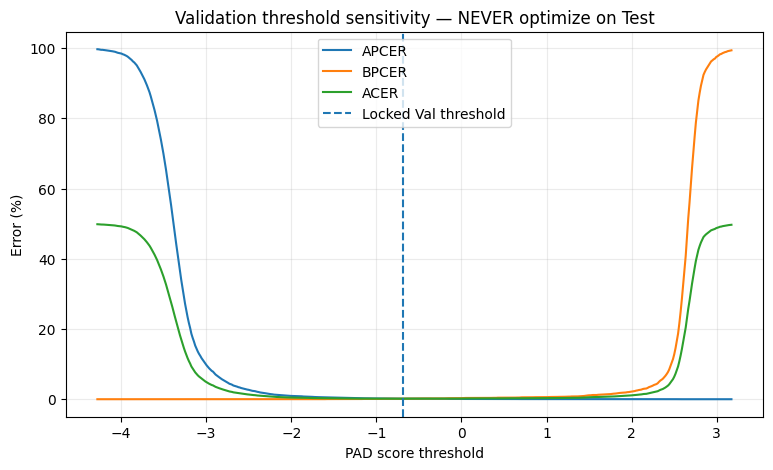

Val operating point APCER≤10%: t=-1.59934, APCER=0.552%, BPCER=0.020%
Val operating point APCER≤5%: t=-1.59934, APCER=0.552%, BPCER=0.020%
Val operating point APCER≤1%: t=-1.59934, APCER=0.552%, BPCER=0.020%


In [9]:

# Cell 9 — Validation-only threshold audit
def threshold_metrics_arrays(df, thresholds):
    y = df["y_binary"].to_numpy(np.int64)
    s = df["pad_score"].to_numpy(np.float64)
    out = []
    for t in thresholds:
        pred = (s < t).astype(np.int64)
        tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
        apcer = fn / max(1, fn + tp)
        bpcer = fp / max(1, fp + tn)
        out.append((t, apcer, bpcer, 0.5*(apcer+bpcer)))
    return pd.DataFrame(out, columns=["threshold","APCER","BPCER","ACER"])

def find_min_acer_threshold(df):
    scores = np.unique(df["pad_score"].to_numpy(np.float64))
    # Exact candidate decision boundaries plus locked threshold.
    cand = np.unique(np.concatenate([
        [np.nextafter(scores[0], -np.inf)],
        scores,
        [np.nextafter(scores[-1], np.inf)],
        [LOCKED_LOGIT_THRESHOLD],
    ]))
    tm = threshold_metrics_arrays(df, cand)
    tm = tm.sort_values(["ACER","APCER","BPCER","threshold"])
    return tm.iloc[0], tm

if val_df is not None:
    best_row, exact_tm = find_min_acer_threshold(val_df)
    print("Recomputed Validation min-ACER threshold:")
    display(best_row.to_frame().T)
    print("Stored locked threshold:", LOCKED_LOGIT_THRESHOLD)
    print("Absolute threshold delta:", abs(float(best_row["threshold"]) - LOCKED_LOGIT_THRESHOLD))

    # Smooth visualization only; selection above remains exact.
    lo, hi = np.percentile(val_df["pad_score"], [0.2, 99.8])
    grid = np.linspace(lo, hi, 500)
    tm_grid = threshold_metrics_arrays(val_df, grid)

    plt.figure(figsize=(9,5))
    plt.plot(tm_grid["threshold"], tm_grid["APCER"]*100, label="APCER")
    plt.plot(tm_grid["threshold"], tm_grid["BPCER"]*100, label="BPCER")
    plt.plot(tm_grid["threshold"], tm_grid["ACER"]*100, label="ACER")
    plt.axvline(LOCKED_LOGIT_THRESHOLD, linestyle="--", label="Locked Val threshold")
    plt.xlabel("PAD score threshold")
    plt.ylabel("Error (%)")
    plt.title("Validation threshold sensitivity — NEVER optimize on Test")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

    for target in [0.10, 0.05, 0.01]:
        feasible = exact_tm[exact_tm["APCER"] <= target]
        if len(feasible):
            row = feasible.sort_values(["BPCER","ACER"]).iloc[0]
            print(
                f"Val operating point APCER≤{target*100:.0f}%: "
                f"t={row.threshold:.5f}, APCER={row.APCER*100:.3f}%, "
                f"BPCER={row.BPCER*100:.3f}%"
            )
        else:
            print(f"No Validation threshold satisfies APCER≤{target*100:.0f}%")


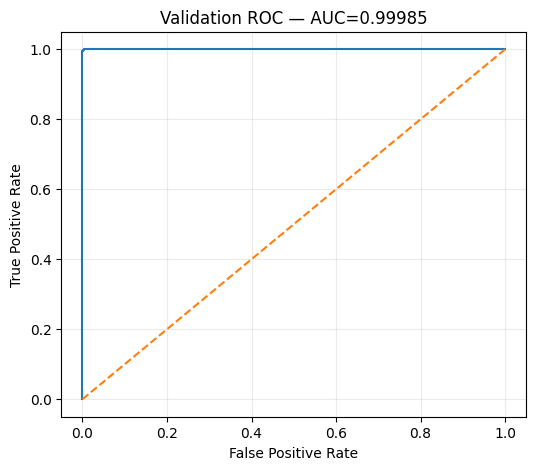

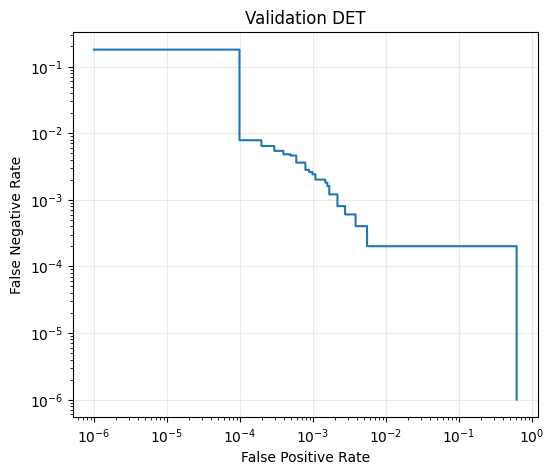

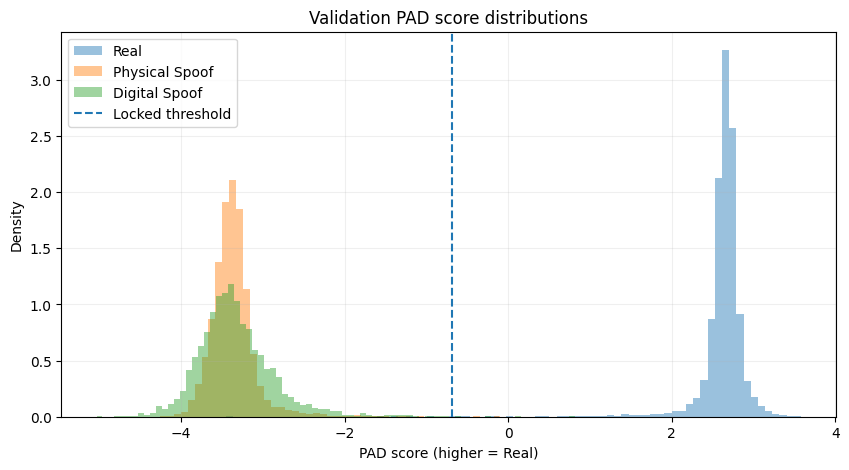

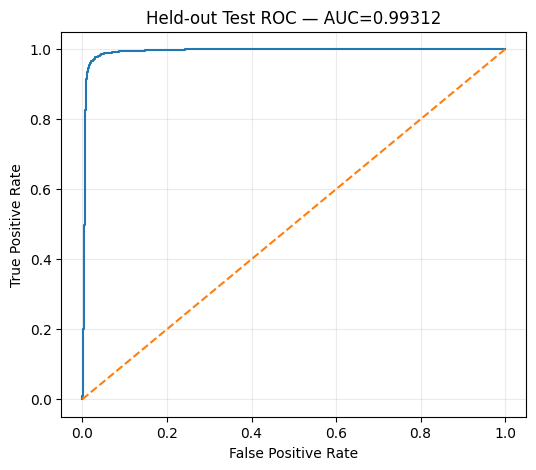

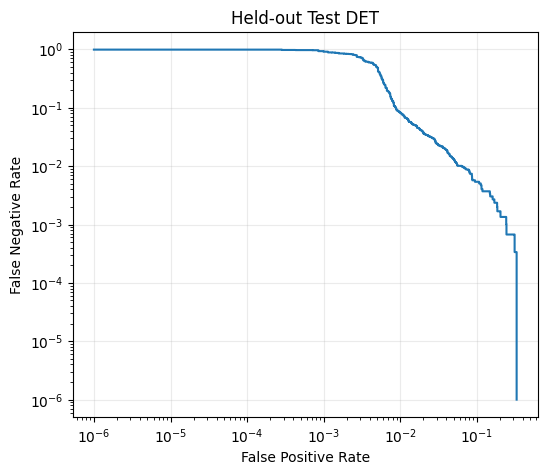

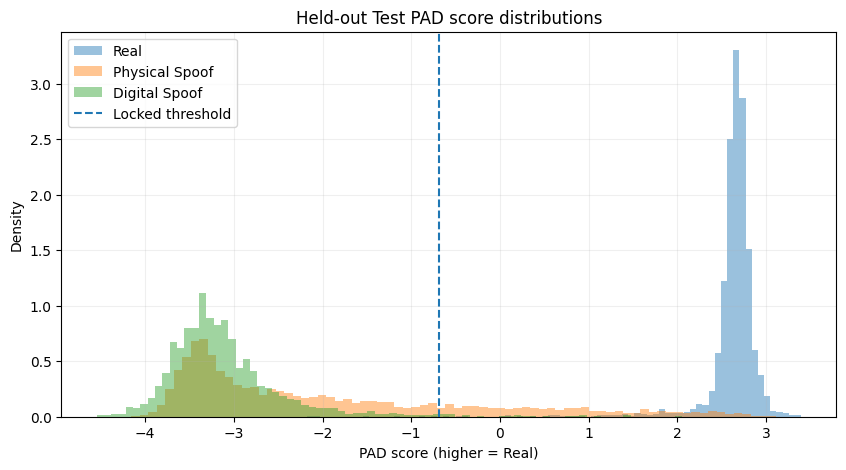

In [10]:

# Cell 10 — ROC / DET / score distributions
def plot_roc_det(df, title_prefix):
    y_real = (df["y_binary"].to_numpy() == 0).astype(np.int64)
    s = df["pad_score"].to_numpy(np.float64)

    fpr, tpr, _ = roc_curve(y_real, s)
    fpr_det, fnr_det, _ = det_curve(y_real, s)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title_prefix} ROC — AUC={roc_auc_score(y_real,s):.5f}")
    plt.grid(alpha=0.25)
    plt.show()

    eps = 1e-6
    plt.figure(figsize=(6,5))
    plt.loglog(np.maximum(fpr_det, eps), np.maximum(fnr_det, eps))
    plt.xlabel("False Positive Rate")
    plt.ylabel("False Negative Rate")
    plt.title(f"{title_prefix} DET")
    plt.grid(alpha=0.25)
    plt.show()

def plot_score_distribution(df, title):
    groups = [
        ("Real", df[df.label3 == 0]["pad_score"]),
        ("Physical Spoof", df[df.label3 == 1]["pad_score"]),
        ("Digital Spoof", df[df.label3 == 2]["pad_score"]),
    ]
    plt.figure(figsize=(10,5))
    for name, values in groups:
        plt.hist(values, bins=80, alpha=0.45, density=True, label=name)
    plt.axvline(LOCKED_LOGIT_THRESHOLD, linestyle="--", label="Locked threshold")
    plt.xlabel("PAD score (higher = Real)")
    plt.ylabel("Density")
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.legend()
    plt.show()

if val_df is not None:
    plot_roc_det(val_df, "Validation")
    plot_score_distribution(val_df, "Validation PAD score distributions")

if test_df is not None:
    plot_roc_det(test_df, "Held-out Test")
    plot_score_distribution(test_df, "Held-out Test PAD score distributions")


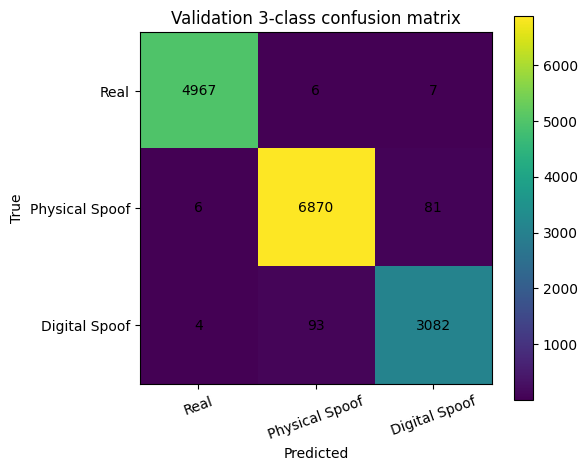

Validation per-attack-code breakdown


,attack_code,attack_name,class,N,mean_score,median_score,score_std,3class_accuracy_%,binary_error_%
9,9,Attack code 9,Digital Spoof,877,-3.296433,-3.396109,0.603017,95.324971,0.228050
10,10,Attack code 10,Digital Spoof,1365,-3.319636,-3.374406,0.412346,99.487179,0.219780
8,8,Attack code 8,Digital Spoof,937,-3.370135,-3.400286,0.451829,94.770544,0.000000
7,7,Attack code 7,Physical Spoof,1013,-3.286516,-3.352627,0.485618,94.076999,0.592300
5,5,Region Mask,Physical Spoof,1169,-3.380647,-3.401268,0.331719,99.743370,0.342173
3,3,Face Mask,Physical Spoof,680,-3.354210,-3.381414,0.318899,99.117647,0.294118
1,1,Attack code 1,Physical Spoof,1021,-3.390269,-3.414854,0.298174,99.020568,0.000000
2,2,Attack code 2,Physical Spoof,695,-3.367866,-3.383733,0.276522,99.568345,0.000000
4,4,Attack code 4,Physical Spoof,1301,-3.344304,-3.344676,0.194632,99.846272,0.000000
6,6,Attack code 6,Physical Spoof,1078,-3.404923,-3.412316,0.187255,99.721707,0.000000


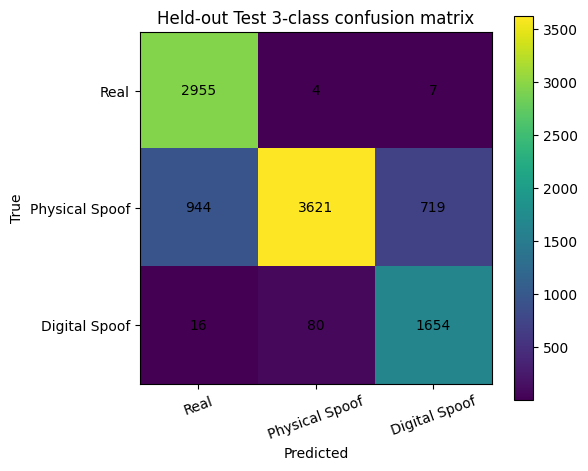

Held-out Test per-attack-code breakdown


,attack_code,attack_name,class,N,mean_score,median_score,score_std,3class_accuracy_%,binary_error_%
8,8,Attack code 8,Digital Spoof,541,-2.961808,-3.128203,0.869560,91.127542,3.142329
9,9,Attack code 9,Digital Spoof,670,-3.105482,-3.205741,0.666072,93.283582,1.044776
10,10,Attack code 10,Digital Spoof,539,-3.226104,-3.322555,0.462988,99.443414,0.556586
7,7,Attack code 7,Physical Spoof,960,-0.160322,-0.031138,1.774220,20.208333,61.979167
5,5,Region Mask,Physical Spoof,915,-1.234945,-1.400321,1.354441,52.568306,32.896175
3,3,Face Mask,Physical Spoof,919,-2.124903,-2.519469,1.481745,71.817193,16.322089
2,2,Attack code 2,Physical Spoof,793,-2.292261,-2.722187,1.328209,84.363178,11.475410
6,6,Attack code 6,Physical Spoof,508,-3.201754,-3.367473,0.567300,97.440945,0.787402
1,1,Attack code 1,Physical Spoof,551,-3.154854,-3.318716,0.564253,91.651543,0.725953
4,4,Attack code 4,Physical Spoof,638,-3.161107,-3.319779,0.580767,96.708464,0.470219


In [11]:

# Cell 11 — 3-class and per-attack breakdown
CLASS_NAMES = {0:"Real", 1:"Physical Spoof", 2:"Digital Spoof"}

def three_class_cm(df, title):
    cm = confusion_matrix(df["label3"], df["pred3"], labels=[0,1,2])
    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(cm)
    ax.set_xticks([0,1,2], [CLASS_NAMES[i] for i in [0,1,2]], rotation=20)
    ax.set_yticks([0,1,2], [CLASS_NAMES[i] for i in [0,1,2]])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, int(cm[i,j]), ha="center", va="center")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

def attack_breakdown(df):
    rows = []
    for code, g in df.groupby("attack_code"):
        label3 = int(g["label3"].mode().iloc[0])
        row = {
            "attack_code": int(code),
            "attack_name": attack_name(code),
            "class": CLASS_NAMES[label3],
            "N": len(g),
            "mean_score": g["pad_score"].mean(),
            "median_score": g["pad_score"].median(),
            "score_std": g["pad_score"].std(),
            "3class_accuracy_%": 100*(g["pred3"] == g["label3"]).mean(),
        }
        if label3 == 0:
            row["binary_error_%"] = 100*(g["pred_binary"] == 1).mean()  # BPCER-like
        else:
            row["binary_error_%"] = 100*(g["pred_binary"] == 0).mean()  # APCER
        rows.append(row)
    return pd.DataFrame(rows).sort_values(["class","binary_error_%"], ascending=[True,False])

if val_df is not None:
    three_class_cm(val_df, "Validation 3-class confusion matrix")
    print("Validation per-attack-code breakdown")
    display(attack_breakdown(val_df))

if test_df is not None:
    three_class_cm(test_df, "Held-out Test 3-class confusion matrix")
    test_attack_table = attack_breakdown(test_df)
    print("Held-out Test per-attack-code breakdown")
    display(test_attack_table)
    test_attack_table.to_csv("/kaggle/working/test_per_attack_breakdown.csv", index=False)


In [12]:

# Cell 12 — Subject-level failure analysis
def subject_breakdown(df):
    rows = []
    for subject, g in df.groupby("subject"):
        real = g[g.y_binary == 0]
        spoof = g[g.y_binary == 1]
        bpcer = np.nan if len(real)==0 else (real.pred_binary == 1).mean()
        apcer = np.nan if len(spoof)==0 else (spoof.pred_binary == 0).mean()
        acer = np.nanmean([apcer, bpcer]) if not (np.isnan(apcer) and np.isnan(bpcer)) else np.nan
        rows.append({
            "subject": subject,
            "N": len(g),
            "N_real": len(real),
            "N_spoof": len(spoof),
            "APCER_%": np.nan if np.isnan(apcer) else apcer*100,
            "BPCER_%": np.nan if np.isnan(bpcer) else bpcer*100,
            "subject_ACER_%": np.nan if np.isnan(acer) else acer*100,
            "mean_score": g.pad_score.mean(),
        })
    return pd.DataFrame(rows)

if val_df is not None:
    val_subject_table = subject_breakdown(val_df)
    print("Worst Validation subjects by subject-level ACER")
    display(val_subject_table.sort_values("subject_ACER_%", ascending=False).head(20))

if test_df is not None:
    test_subject_table = subject_breakdown(test_df)
    print("Worst Held-out Test subjects by subject-level ACER")
    display(test_subject_table.sort_values("subject_ACER_%", ascending=False).head(20))
    test_subject_table.to_csv("/kaggle/working/test_subject_breakdown.csv", index=False)


Worst Validation subjects by subject-level ACER


,subject,N,N_real,N_spoof,APCER_%,BPCER_%,subject_ACER_%,mean_score
118,5095,63,23,40,10.000000,0.000000,5.000000,-0.792317
150,6218,72,21,51,9.803922,0.000000,4.901961,-1.077703
47,2881,21,21,0,NaN,4.761905,4.761905,2.446145
242,9722,70,30,40,7.500000,0.000000,3.750000,-0.463355
49,3010,70,30,40,5.000000,0.000000,2.500000,-0.680452
195,7733,60,20,40,0.000000,5.000000,2.500000,-1.460579
182,7275,69,29,40,0.000000,3.448276,1.724138,-0.964142
85,4151,80,30,50,0.000000,3.333333,1.666667,-1.154696
176,7159,66,30,36,0.000000,3.333333,1.666667,-0.678305
206,8427,46,30,16,0.000000,3.333333,1.666667,0.529689


Worst Held-out Test subjects by subject-level ACER


,subject,N,N_real,N_spoof,APCER_%,BPCER_%,subject_ACER_%,mean_score
486,7332,2,0,2,100.000000,NaN,100.000000,0.353934
921,9735,5,0,5,80.000000,NaN,80.000000,0.897870
46,5028,4,0,4,75.000000,NaN,75.000000,-0.409658
142,5523,17,0,17,58.823529,NaN,58.823529,-0.558869
38,4989,9,0,9,55.555556,NaN,55.555556,-1.046237
175,5723,28,0,28,53.571429,NaN,53.571429,-0.676990
632,8191,17,1,16,100.000000,0.0,50.000000,2.068606
719,8659,8,7,1,100.000000,0.0,50.000000,2.629919
260,6195,8,6,2,100.000000,0.0,50.000000,2.165290
320,6472,6,3,3,100.000000,0.0,50.000000,2.312354


In [13]:

# Cell 13 — Subject-cluster bootstrap confidence intervals
def metric_vector(y, s, threshold):
    pred = (s < threshold).astype(np.int64)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0,1]).ravel()
    apcer = fn / max(1, fn+tp)
    bpcer = fp / max(1, fp+tn)
    acer = 0.5*(apcer+bpcer)
    acc = (pred == y).mean()
    try:
        auc = roc_auc_score(1-y, s)
    except ValueError:
        auc = np.nan
    return np.array([acc, apcer, bpcer, acer, auc], dtype=np.float64)

def subject_cluster_bootstrap(df, reps=BOOTSTRAP_REPS, alpha=BOOTSTRAP_ALPHA, seed=SEED):
    subjects = df["subject"].astype(str).to_numpy()
    y = df["y_binary"].to_numpy(np.int64)
    s = df["pad_score"].to_numpy(np.float64)
    unique_subjects = np.unique(subjects)
    idx_by_subject = {sub: np.flatnonzero(subjects == sub) for sub in unique_subjects}

    rng = np.random.default_rng(seed)
    samples = []
    for _ in tqdm(range(reps), desc="Subject-cluster bootstrap"):
        sampled_subjects = rng.choice(unique_subjects, size=len(unique_subjects), replace=True)
        idx = np.concatenate([idx_by_subject[sub] for sub in sampled_subjects])
        samples.append(metric_vector(y[idx], s[idx], LOCKED_LOGIT_THRESHOLD))
    arr = np.vstack(samples)

    names = ["Accuracy","APCER","BPCER","ACER","AUC"]
    point = metric_vector(y, s, LOCKED_LOGIT_THRESHOLD)
    lo = np.nanpercentile(arr, 100*(alpha/2), axis=0)
    hi = np.nanpercentile(arr, 100*(1-alpha/2), axis=0)
    table = pd.DataFrame({
        "metric": names,
        "point_%": point*100,
        f"CI_{100*(alpha/2):.1f}%": lo*100,
        f"CI_{100*(1-alpha/2):.1f}%": hi*100,
    })
    return table

if val_df is not None:
    print("Validation subject-cluster bootstrap CI")
    display(subject_cluster_bootstrap(val_df))

if test_df is not None:
    print("Held-out Test subject-cluster bootstrap CI")
    test_ci = subject_cluster_bootstrap(test_df)
    display(test_ci)
    test_ci.to_csv("/kaggle/working/test_bootstrap_ci.csv", index=False)


Validation subject-cluster bootstrap CI


Subject-cluster bootstrap:   0%|          | 0/500 [00:00<?, ?it/s]

,metric,point_%,CI_2.5%,CI_97.5%
0,Accuracy,99.847843,99.747847,99.934698
1,APCER,0.167719,0.043566,0.304159
2,BPCER,0.120482,0.039669,0.226786
3,ACER,0.144100,0.069222,0.230595
4,AUC,99.985122,99.958717,99.999696


Held-out Test subject-cluster bootstrap CI


Subject-cluster bootstrap:   0%|          | 0/500 [00:00<?, ?it/s]

,metric,point_%,CI_2.5%,CI_97.5%
0,Accuracy,88.170000,86.192570,90.054130
1,APCER,16.704578,13.872559,19.421918
2,BPCER,0.269724,0.101589,0.469259
3,ACER,8.487151,7.105597,9.853972
4,AUC,99.312380,99.010797,99.565916


Validation: Brier=0.003631, ECE=0.046011


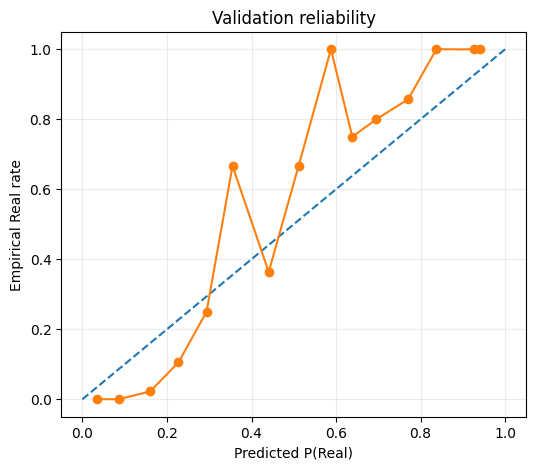

Held-out Test: Brier=0.060726, ECE=0.110318


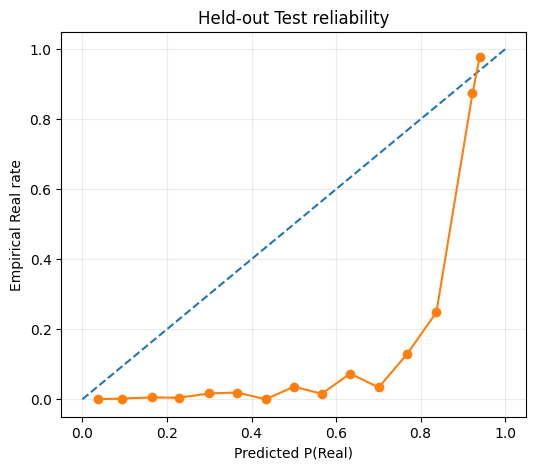

In [14]:

# Cell 14 — Probability calibration: reliability, ECE, Brier
def calibration_report(df, n_bins=CALIBRATION_BINS, title="Calibration"):
    y_real = (df["y_binary"].to_numpy() == 0).astype(np.int64)
    p = df["p_real"].to_numpy(np.float64)

    brier = brier_score_loss(y_real, p)
    bins = np.linspace(0, 1, n_bins+1)
    bin_ids = np.clip(np.digitize(p, bins) - 1, 0, n_bins-1)

    rows = []
    ece = 0.0
    for b in range(n_bins):
        mask = bin_ids == b
        if not mask.any():
            continue
        conf = p[mask].mean()
        acc = y_real[mask].mean()
        frac = mask.mean()
        ece += frac * abs(acc-conf)
        rows.append((b, mask.sum(), conf, acc, frac))

    cal = pd.DataFrame(rows, columns=["bin","N","mean_p_real","empirical_real_rate","fraction"])
    print(f"{title}: Brier={brier:.6f}, ECE={ece:.6f}")

    plt.figure(figsize=(6,5))
    plt.plot([0,1],[0,1], linestyle="--")
    plt.plot(cal["mean_p_real"], cal["empirical_real_rate"], marker="o")
    plt.xlabel("Predicted P(Real)")
    plt.ylabel("Empirical Real rate")
    plt.title(f"{title} reliability")
    plt.grid(alpha=0.25)
    plt.show()
    return {"Brier": brier, "ECE": ece, "table": cal}

if val_df is not None:
    val_cal = calibration_report(val_df, title="Validation")
if test_df is not None:
    test_cal = calibration_report(test_df, title="Held-out Test")


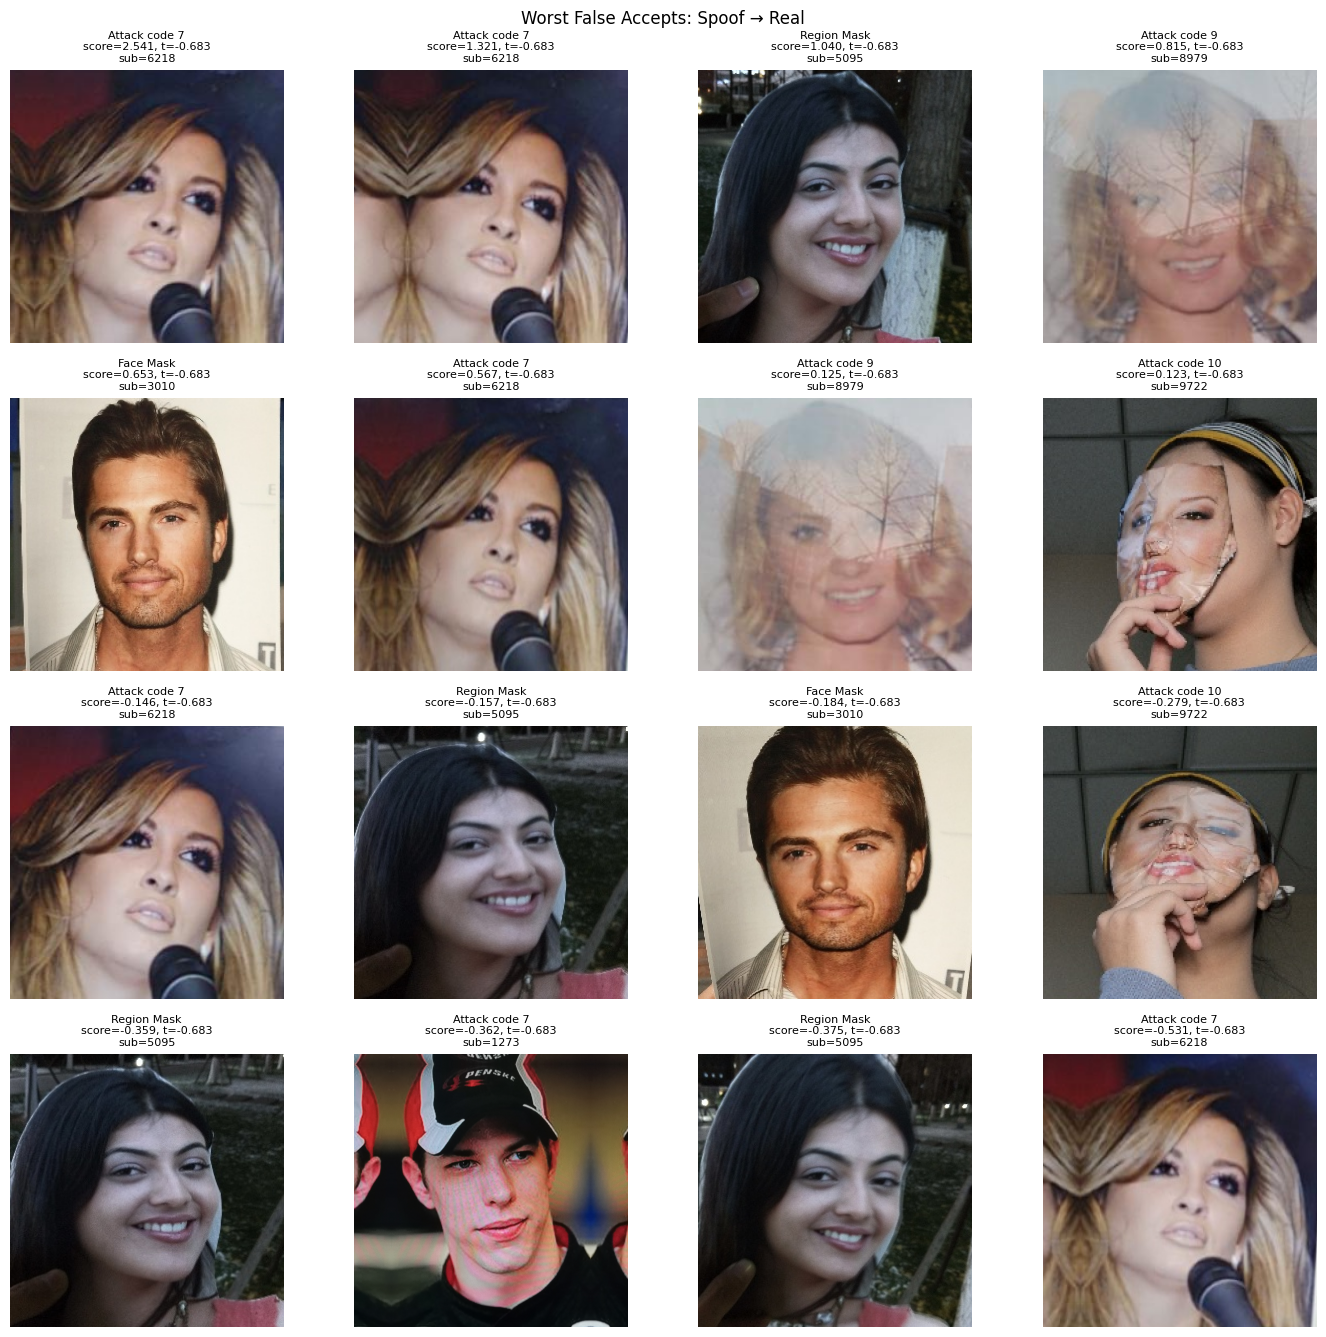

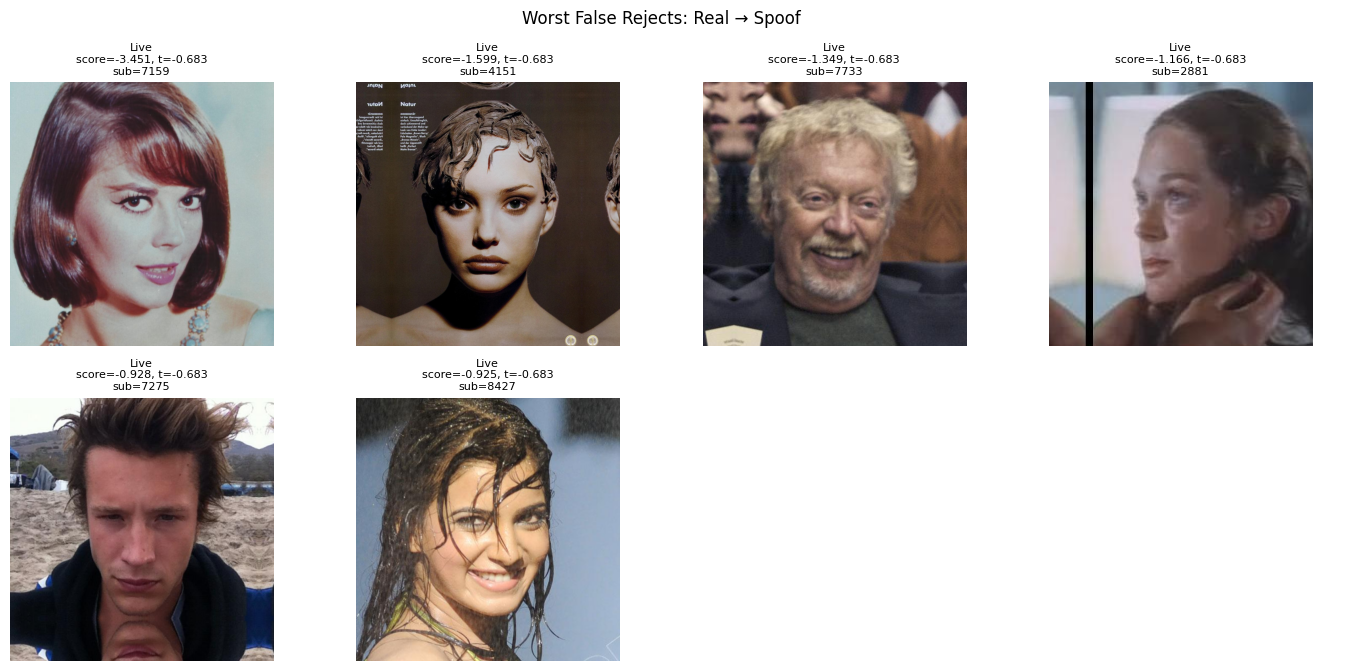

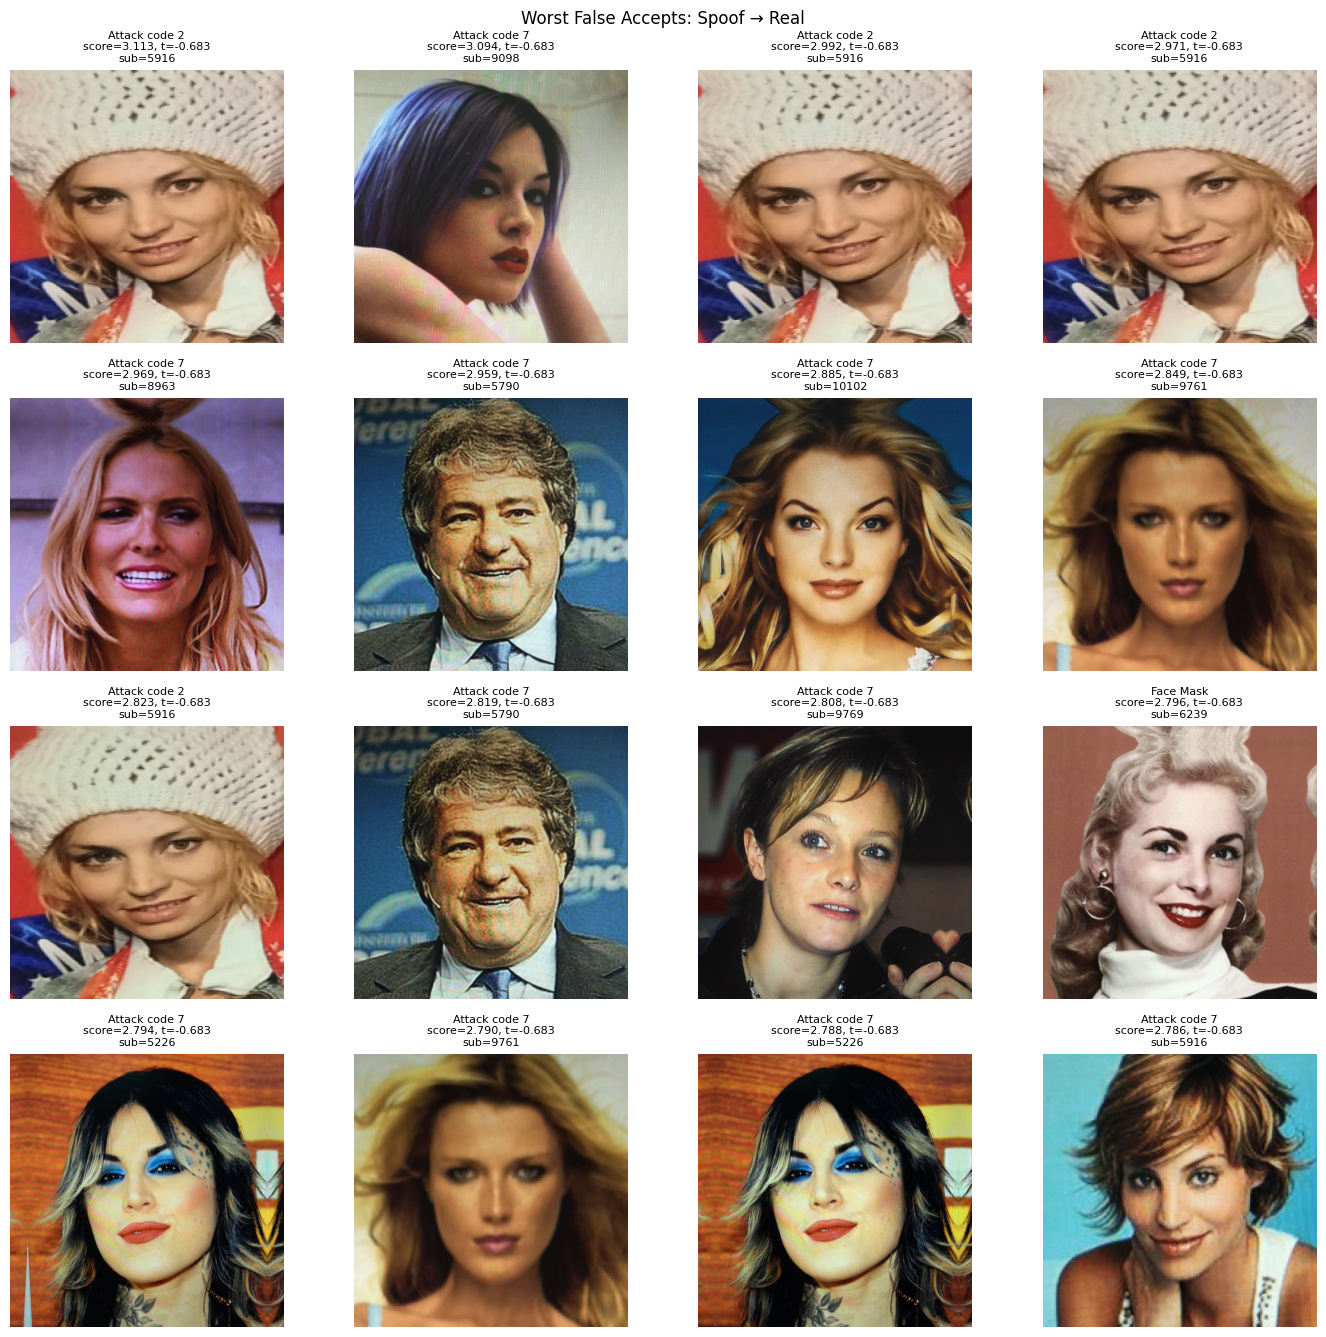

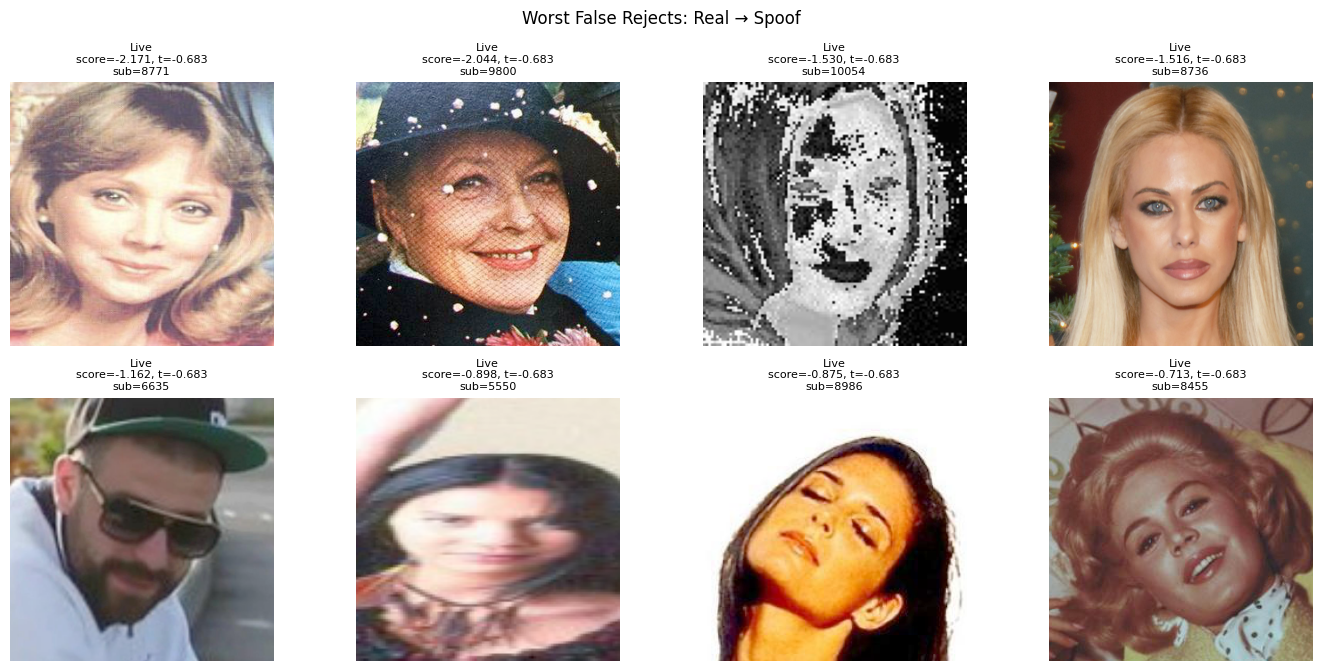

In [15]:

# Cell 15 — Failure galleries
def metadata_for_key(key):
    if key in train_meta:
        return train_meta[key]
    return test_meta[key]

def show_failure_gallery(df, error_type="false_accept", n=ERROR_GALLERY_N):
    if error_type == "false_accept":
        # Spoof -> Real: positive margin means accepted as Real; show worst/highest scores first.
        subset = df[(df.y_binary == 1) & (df.pred_binary == 0)].sort_values("pad_score", ascending=False)
        title = "Worst False Accepts: Spoof → Real"
    else:
        subset = df[(df.y_binary == 0) & (df.pred_binary == 1)].sort_values("pad_score", ascending=True)
        title = "Worst False Rejects: Real → Spoof"

    if subset.empty:
        print("No errors for:", error_type)
        return

    subset = subset.head(n)
    cols = 4
    rows = math.ceil(len(subset) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 3.4*rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, (_, row) in zip(axes, subset.iterrows()):
        crop = read_crop_rgb(DATA_ROOT, row["key"])
        ax.imshow(crop)
        ax.set_title(
            f"{attack_name(row.attack_code)}\n"
            f"score={row.pad_score:.3f}, t={LOCKED_LOGIT_THRESHOLD:.3f}\n"
            f"sub={row.subject}",
            fontsize=8,
        )
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

if val_df is not None:
    show_failure_gallery(val_df, "false_accept")
    show_failure_gallery(val_df, "false_reject")

if test_df is not None:
    show_failure_gallery(test_df, "false_accept")
    show_failure_gallery(test_df, "false_reject")


In [16]:

# Cell 16 — Optional PyTorch ↔ ONNX parity on real CelebA inputs
if RUN_ONNX_PARITY:
    if not ORT_AVAILABLE:
        print("Skipping ONNX parity: ONNX Runtime unavailable")
    elif ONNX_PATH is None:
        print("Skipping ONNX parity: no *_best.onnx found")
    else:
        providers = ort.get_available_providers()
        preferred = [p for p in ["CUDAExecutionProvider","CPUExecutionProvider"] if p in providers]
        sess = ort.InferenceSession(str(ONNX_PATH), providers=preferred or providers)
        input_name = sess.get_inputs()[0].name

        rng = np.random.default_rng(SEED)
        source_ds = val_dataset if len(val_dataset) else test_dataset
        idxs = rng.choice(len(source_ds), size=min(ONNX_PARITY_SAMPLES, len(source_ds)), replace=False)

        max_diffs = []
        for start in tqdm(range(0, len(idxs), BATCH_SIZE), desc="ONNX parity"):
            batch_idx = idxs[start:start+BATCH_SIZE]
            x = torch.stack([source_ds[int(i)]["image"] for i in batch_idx])
            with torch.inference_mode():
                pt = model(x.to(device)).cpu().numpy()
            oo = sess.run(None, {input_name: x.numpy()})[0]
            max_diffs.append(np.max(np.abs(pt-oo)))

        print("ONNX provider:", sess.get_providers())
        print("Max absolute logit diff:", float(np.max(max_diffs)))
        print("Mean batch max diff:", float(np.mean(max_diffs)))
        assert float(np.max(max_diffs)) < 1e-4, "PyTorch/ONNX parity failed"


Skipping ONNX parity: no *_best.onnx found


In [17]:

# Cell 17 — Optional latency benchmark
def benchmark_pytorch(batch_size=1):
    x = torch.randn(batch_size, 3, INPUT_SIZE, INPUT_SIZE, device=device)
    model.eval()
    with torch.inference_mode():
        for _ in range(LATENCY_WARMUP):
            _ = model(x)
        if device.type == "cuda":
            torch.cuda.synchronize()
        times = []
        for _ in range(LATENCY_ITERS):
            t0 = time.perf_counter()
            _ = model(x)
            if device.type == "cuda":
                torch.cuda.synchronize()
            times.append((time.perf_counter()-t0)*1000)
    return np.asarray(times)

if RUN_LATENCY_BENCHMARK:
    for bs in [1, 8, 32]:
        t = benchmark_pytorch(bs)
        per_image = t / bs
        print(
            f"PyTorch {device.type} batch={bs}: "
            f"batch median={np.median(t):.3f} ms, "
            f"per-image median={np.median(per_image):.3f} ms"
        )

    if ORT_AVAILABLE and ONNX_PATH is not None:
        providers = ort.get_available_providers()
        preferred = [p for p in ["CUDAExecutionProvider","CPUExecutionProvider"] if p in providers]
        sess_lat = ort.InferenceSession(str(ONNX_PATH), providers=preferred or providers)
        name = sess_lat.get_inputs()[0].name
        x = np.random.randn(1,3,INPUT_SIZE,INPUT_SIZE).astype(np.float32)
        for _ in range(LATENCY_WARMUP):
            sess_lat.run(None, {name:x})
        times=[]
        for _ in range(LATENCY_ITERS):
            t0=time.perf_counter()
            sess_lat.run(None,{name:x})
            times.append((time.perf_counter()-t0)*1000)
        print(
            f"ONNX {sess_lat.get_providers()[0]} batch=1: "
            f"median={np.median(times):.3f} ms, p95={np.percentile(times,95):.3f} ms"
        )


PyTorch cuda batch=1: batch median=5.751 ms, per-image median=5.751 ms
PyTorch cuda batch=8: batch median=5.976 ms, per-image median=0.747 ms
PyTorch cuda batch=32: batch median=22.384 ms, per-image median=0.699 ms


In [18]:

# Cell 18 — Optional controlled robustness stress test on Validation subset
def transform_rgb(img, kind):
    if kind == "clean":
        return img
    if kind == "dark20":
        return np.clip(img.astype(np.float32)*0.80, 0, 255).astype(np.uint8)
    if kind == "bright20":
        return np.clip(img.astype(np.float32)*1.20, 0, 255).astype(np.uint8)
    if kind == "blur3":
        return cv2.GaussianBlur(img, (3,3), 0)
    if kind == "jpeg70":
        bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        ok, enc = cv2.imencode(".jpg", bgr, [cv2.IMWRITE_JPEG_QUALITY, 70])
        if not ok:
            raise RuntimeError("JPEG encoding failed")
        dec = cv2.imdecode(enc, cv2.IMREAD_COLOR)
        return cv2.cvtColor(dec, cv2.COLOR_BGR2RGB)
    raise ValueError(kind)

def infer_transformed_keys(keys, meta, kind):
    y_list, score_list = [], []
    tensors = []
    labels = []
    for key in tqdm(keys, desc=f"Prepare {kind}"):
        img = read_crop_rgb(DATA_ROOT, key)
        img = transform_rgb(img, kind)
        tensors.append(runtime_preprocess_rgb(img))
        labels.append(1 if label_of(meta[key]) > 0 else 0)

        if len(tensors) == BATCH_SIZE:
            x = torch.stack(tensors).to(device)
            with torch.inference_mode():
                d = logits_to_pad_score(model(x)).cpu().numpy()
            score_list.extend(d.tolist()); y_list.extend(labels)
            tensors, labels = [], []

    if tensors:
        x = torch.stack(tensors).to(device)
        with torch.inference_mode():
            d = logits_to_pad_score(model(x)).cpu().numpy()
        score_list.extend(d.tolist()); y_list.extend(labels)

    temp = pd.DataFrame({"y_binary": y_list, "pad_score": score_list})
    temp["pred_binary"] = (temp.pad_score < LOCKED_LOGIT_THRESHOLD).astype(int)
    # add minimum columns needed by metrics helper
    temp["pred3"] = 0; temp["label3"] = 0
    return metrics_from_df(temp, LOCKED_LOGIT_THRESHOLD)

if RUN_ROBUSTNESS_STRESS:
    rng = np.random.default_rng(SEED)
    n = min(STRESS_SAMPLE_SIZE, len(val_keys))
    stress_keys = rng.choice(val_keys, size=n, replace=False).tolist()
    rows=[]
    for kind in ["clean","dark20","bright20","blur3","jpeg70"]:
        m = infer_transformed_keys(stress_keys, train_meta, kind)
        rows.append({
            "condition": kind,
            "N": n,
            "APCER_%": m["APCER"]*100,
            "BPCER_%": m["BPCER"]*100,
            "ACER_%": m["ACER"]*100,
            "AUC_%": m["AUC"]*100,
        })
    stress_table = pd.DataFrame(rows)
    display(stress_table)
    stress_table.to_csv("/kaggle/working/robustness_stress_test.csv", index=False)
else:
    print("Robustness stress test disabled. Set RUN_ROBUSTNESS_STRESS=True if needed.")


Robustness stress test disabled. Set RUN_ROBUSTNESS_STRESS=True if needed.


CelebA Real N: 2966
Camera Real N: 1
CelebA Real median score: 2.6693841218948364
Camera Real median score: -1.6900468501774273
Camera frames below locked threshold: 100.00%


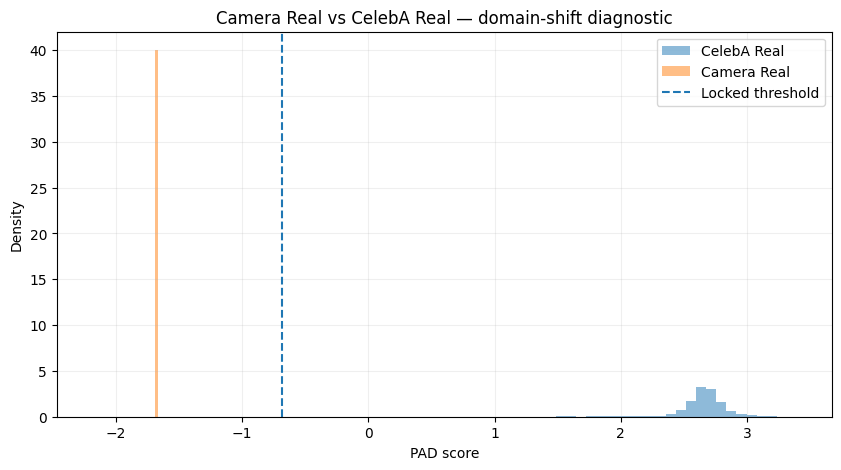

In [19]:

# Cell 19 — Optional Camera-vs-CelebA score comparison
if CAMERA_DIAGNOSTIC_CSV:
    cam = pd.read_csv(CAMERA_DIAGNOSTIC_CSV)
    required = {"pad_score_correct"}
    missing = required - set(cam.columns)
    if missing:
        raise ValueError(f"Camera CSV missing columns: {missing}")

    celeba_source = test_df if test_df is not None else val_df
    celeba_real = celeba_source[celeba_source.y_binary == 0]["pad_score"].to_numpy()
    camera_scores = cam["pad_score_correct"].dropna().to_numpy()

    print("CelebA Real N:", len(celeba_real))
    print("Camera Real N:", len(camera_scores))
    print("CelebA Real median score:", np.median(celeba_real))
    print("Camera Real median score:", np.median(camera_scores))
    print(
        "Camera frames below locked threshold:",
        f"{100*np.mean(camera_scores < LOCKED_LOGIT_THRESHOLD):.2f}%"
    )

    plt.figure(figsize=(10,5))
    plt.hist(celeba_real, bins=70, density=True, alpha=0.50, label="CelebA Real")
    plt.hist(camera_scores, bins=40, density=True, alpha=0.50, label="Camera Real")
    plt.axvline(LOCKED_LOGIT_THRESHOLD, linestyle="--", label="Locked threshold")
    plt.xlabel("PAD score")
    plt.ylabel("Density")
    plt.title("Camera Real vs CelebA Real — domain-shift diagnostic")
    plt.grid(alpha=0.2)
    plt.legend()
    plt.show()
else:
    print(
        "No camera CSV configured. Run camera_pad_diagnostic.py locally, "
        "upload its CSV to Kaggle, then set CAMERA_DIAGNOSTIC_CSV."
    )


In [20]:

# Cell 20 — Save compact evaluation summary
report = {
    "model": str(BEST_PTH),
    "protocol_version": runtime_cfg.get("protocol_version"),
    "split_manifest": str(SPLIT_MANIFEST),
    "locked_logit_threshold": LOCKED_LOGIT_THRESHOLD,
    "locked_predictor_probability": LOCKED_PROB_THRESHOLD,
    "runtime_contract": {
        "input_size": INPUT_SIZE,
        "crop_factor": BBOX_EXPANSION_FACTOR,
        "color_order": runtime_cfg.get("color_order"),
        "mean": CELEBA_MEAN,
        "std": CELEBA_STD,
        "apply_gamma": APPLY_GAMMA,
    },
    "metrics_percent": {},
}

for name, m in summaries.items():
    report["metrics_percent"][name] = {
        k: (v*100 if k in {"Accuracy","APCER","BPCER","ACER","AUC","EER","3class_accuracy"} else v)
        for k, v in m.items()
        if k not in {"EER_threshold"}
    }
    report["metrics_percent"][name]["EER_threshold"] = m["EER_threshold"]

out = Path("/kaggle/working/pad_deep_evaluation_summary.json")
with open(out, "w") as f:
    json.dump(report, f, indent=2)

if val_df is not None:
    val_df.to_csv("/kaggle/working/validation_predictions_detailed.csv", index=False)
if test_df is not None:
    test_df.to_csv("/kaggle/working/test_predictions_detailed.csv", index=False)

print("Saved:", out)
print("Deep evaluation complete.")


Saved: /kaggle/working/pad_deep_evaluation_summary.json
Deep evaluation complete.
